In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns





df = pd.read_csv("C:/Users/sabin/Desktop/Ecommerce-Analysis/Data/clean/merged_data.csv")
df.head()


                 


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12


In [2]:
#Basic Overview
df.shape
df.info()
df.describe(include = 'all')
df.isna().sum()
#The dataset contains transactional-level e-commerce data including orders, customers, payments, and product details.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   customer_unique_id             118434 non-null  object 
 9   customer_zip_code_prefix       118434 non-null  int64  
 10  customer_city                  118434 non-null  object 
 11  customer_state                 118434 non-null  object 
 12  order_item_id                 

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price                             830
freight_value                     830
product_category_name            2528
product_name_lenght              2528
product_description_lenght       2528
product_photos_qty               2528
product_weight_g                  850
product_length_cm                 850
product_height_cm                 850
product_width_cm                  850
payment_sequ

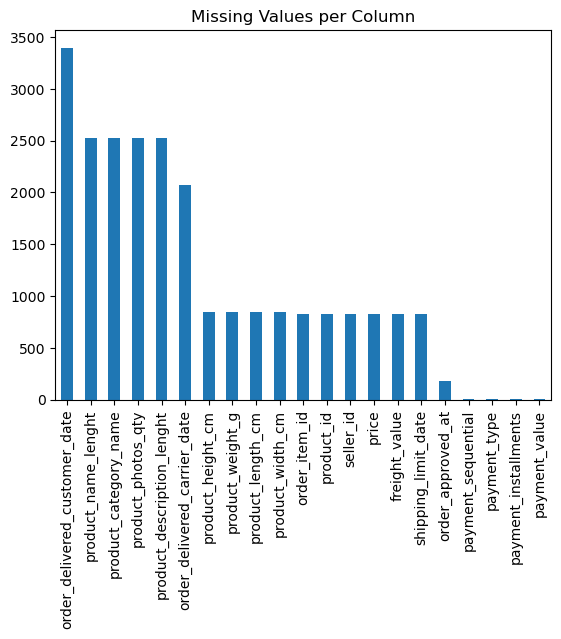

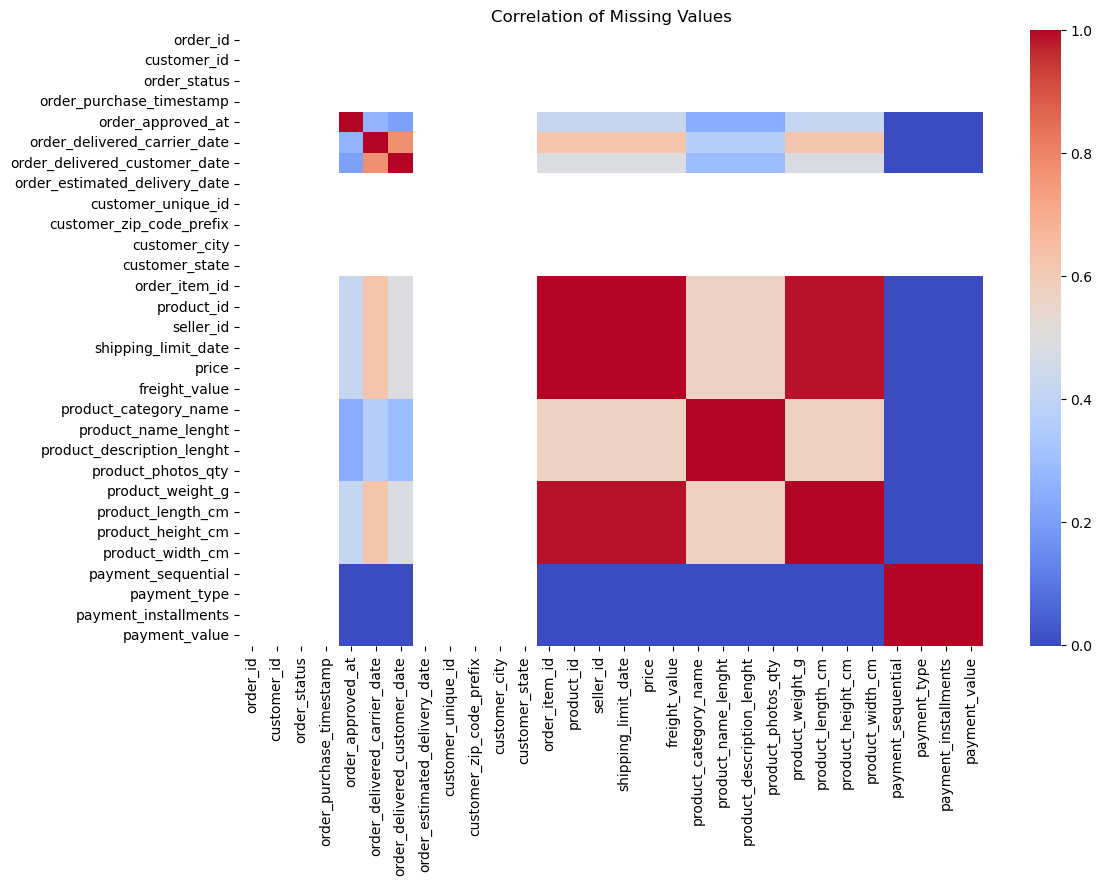

In [3]:
#Missing Values table
# Missing values table
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

# Bar chart
missing.plot(kind='bar', title='Missing Values per Column')
plt.show()

#  - correlation of missingness
plt.figure(figsize=(12, 8))
# Convert boolean mask of missing values to float for correlation calculation
missing_corr = df.isna().astype(float).corr()
sns.heatmap(missing_corr, annot=False, cmap='coolwarm')
plt.title('Correlation of Missing Values')
plt.show()

In [4]:
#keep missing product category name as unknown
df['product_category_name']=df["product_category_name"].fillna("unknown")


In [5]:
df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price                             830
freight_value                     830
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
product_category_name               0
product_name_lenght              2528
product_description_lenght       2528
product_photos_qty               2528
product_weig

In [4]:
#convert date
date_cols = ['order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors = 'coerce')
#extract date
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['order_year'] = df['order_purchase_timestamp'].dt.year



 Analysis

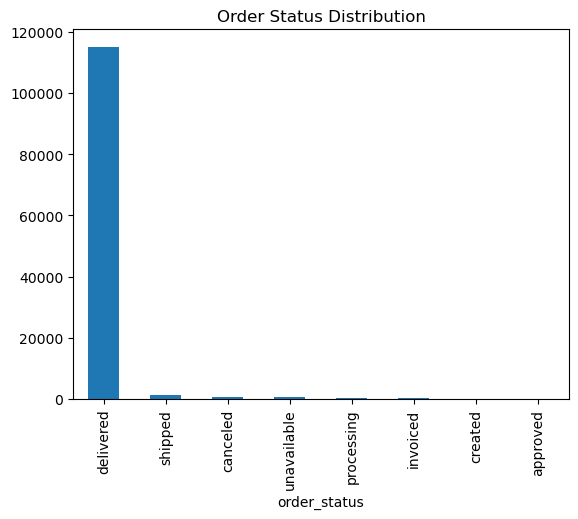

In [5]:
# Order status distribution
df['order_status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.show()


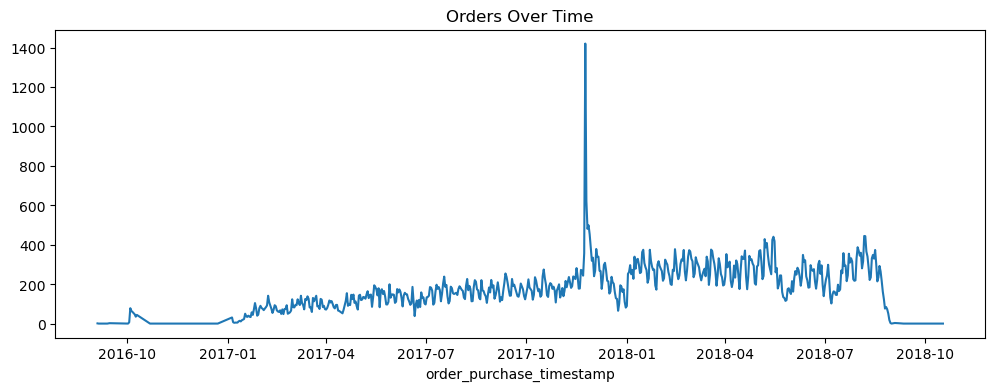

In [6]:
#Orders volume over time (to check growth trend)
df["order_purchase_timestamp"].dt.date.value_counts().sort_index().plot(figsize=(12,4))
plt.title("Orders Over Time")
plt.show()


Pricing Analysis 


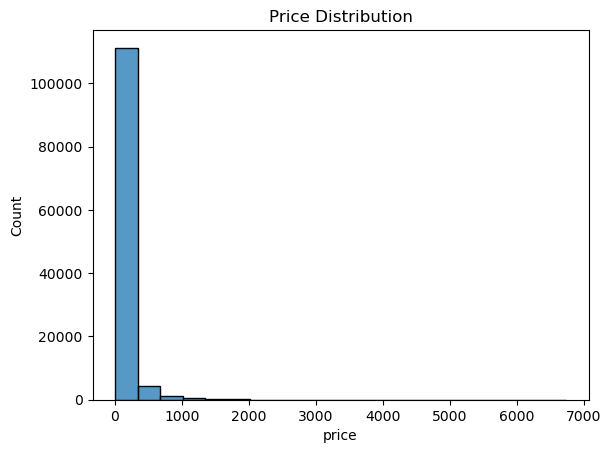

In [7]:
#Price Distribution (typical product price ranges)
sns.histplot(df['price'], bins=20)
plt.title("Price Distribution")
plt.show()


In [8]:
# Price vs Sales Volume
display(df.groupby('product_category_name')['price'].mean())


product_category_name
agro_industria_e_comercio    332.706151
alimentos                     57.261293
alimentos_bebidas             56.621211
artes                        112.885708
artes_e_artesanato            75.583750
                                ...    
sinalizacao_e_seguranca      107.387114
tablets_impressao_imagem      90.118506
telefonia                     71.891370
telefonia_fixa               227.679926
utilidades_domesticas         90.630455
Name: price, Length: 73, dtype: float64

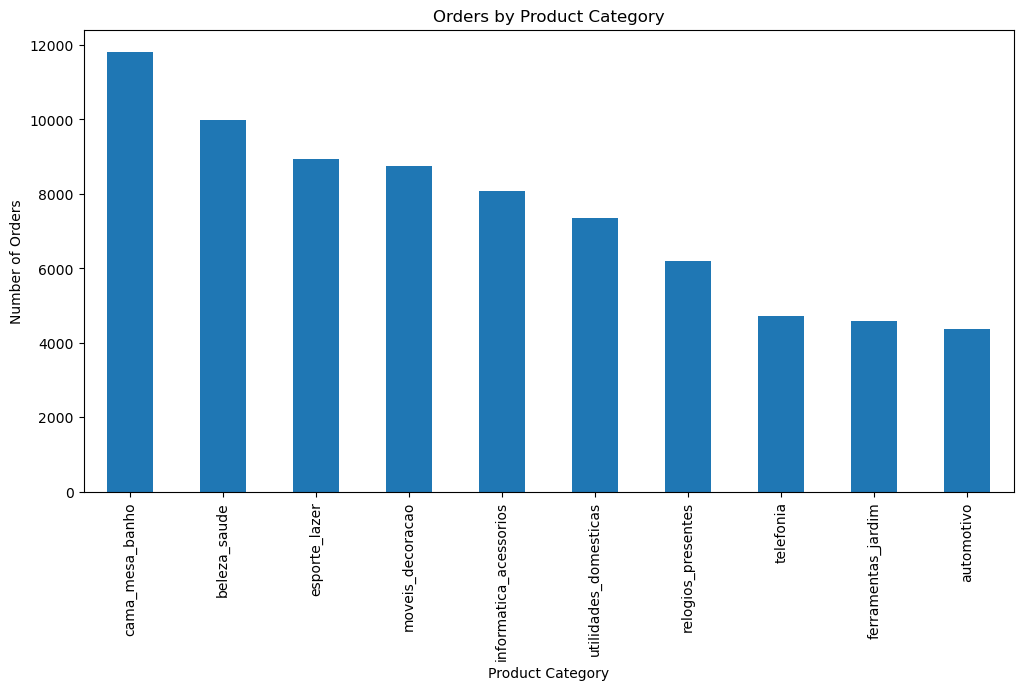

In [8]:
#Top 10 products
category_counts = (
    df.groupby('product_category_name')['order_id']
      .count()
      .sort_values(ascending=False)
).head(10)

plt.figure(figsize=(12,6))
category_counts.plot(kind='bar')
plt.title('Orders by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.show()

In [10]:
#Category Pricing Analysis

#create aggregated table
category_analysis = df.groupby(
    'product_category_name'
).agg(
    average_price=('price', 'mean'),
    total_revenue=('price', 'sum'),
    order_volume=('order_id', 'count')
).reset_index().sort_values(
    by='total_revenue',
    ascending=False)


#display top categories
category_analysis.head(10)

,product_category_name,average_price,total_revenue,order_volume
11,beleza_saude,130.074263,1297490.77,9975
66,relogios_presentes,202.087292,1253143.30,6201
13,cama_mesa_banho,92.408950,1092551.02,11823
32,esporte_lazer,114.476952,1023996.34,8945
44,informatica_acessorios,116.589652,942277.57,8082
54,moveis_decoracao,87.499301,765093.89,8744
72,utilidades_domesticas,90.630455,666587.00,7355
26,cool_stuff,166.117254,662309.49,3987
8,automotivo,140.843231,616752.51,4379
40,ferramentas_jardim,113.296358,518217.54,4574


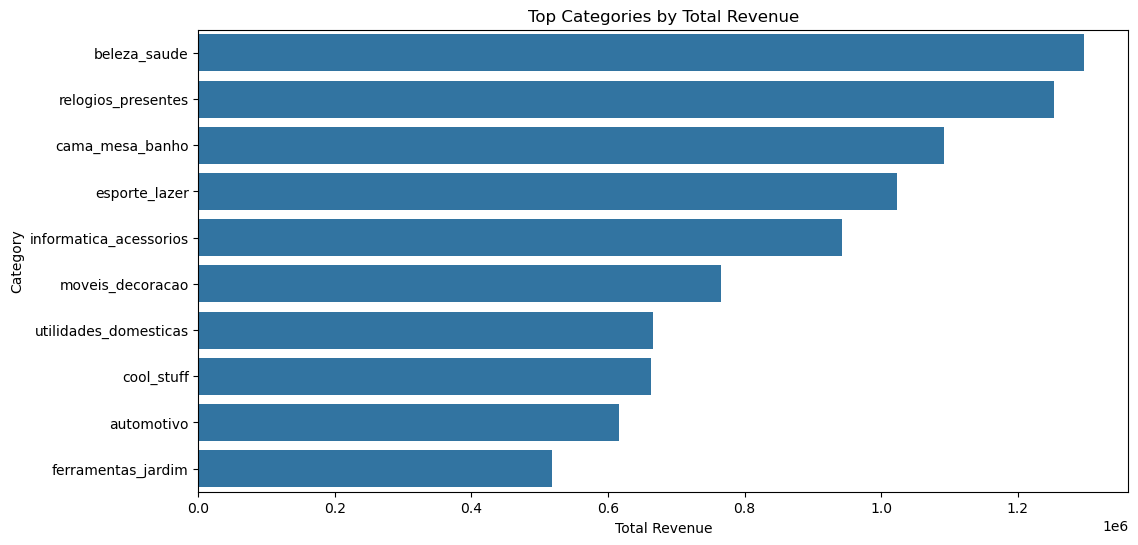

In [11]:
#total revenue by category
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_analysis.head(10),
    x='total_revenue',
    y='product_category_name'
)

plt.title('Top Categories by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Category')

plt.show()

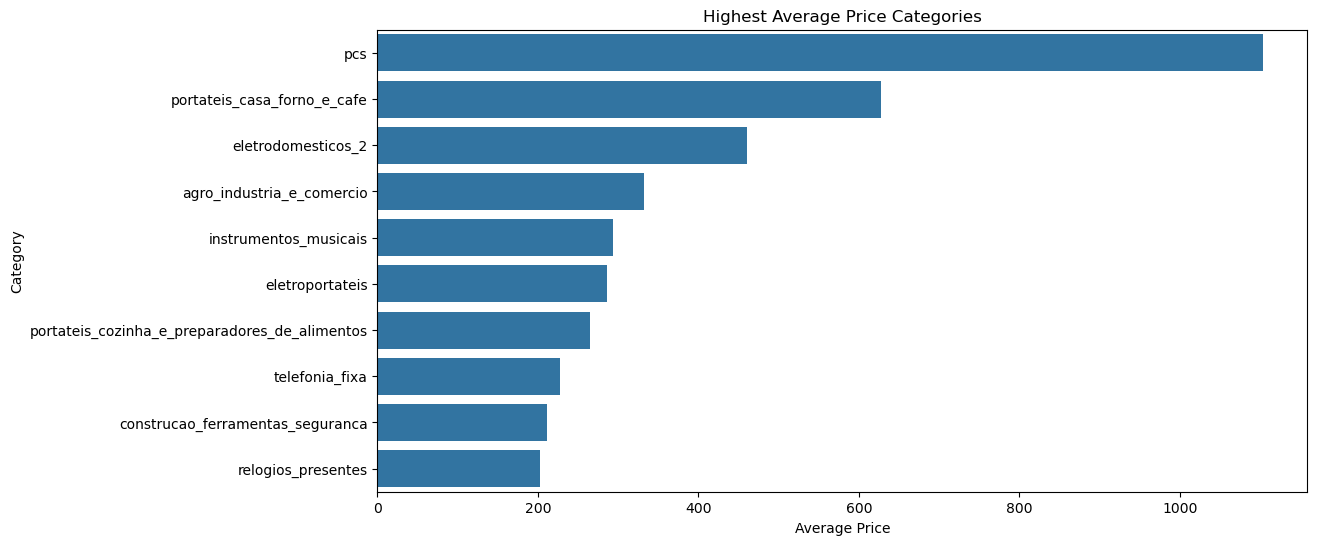

In [12]:
#Average price by Category

top_price = category_analysis.sort_values(
    by='average_price',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_price,
    x='average_price',
    y='product_category_name'
)

plt.title('Highest Average Price Categories')
plt.xlabel('Average Price')
plt.ylabel('Category')

plt.show()

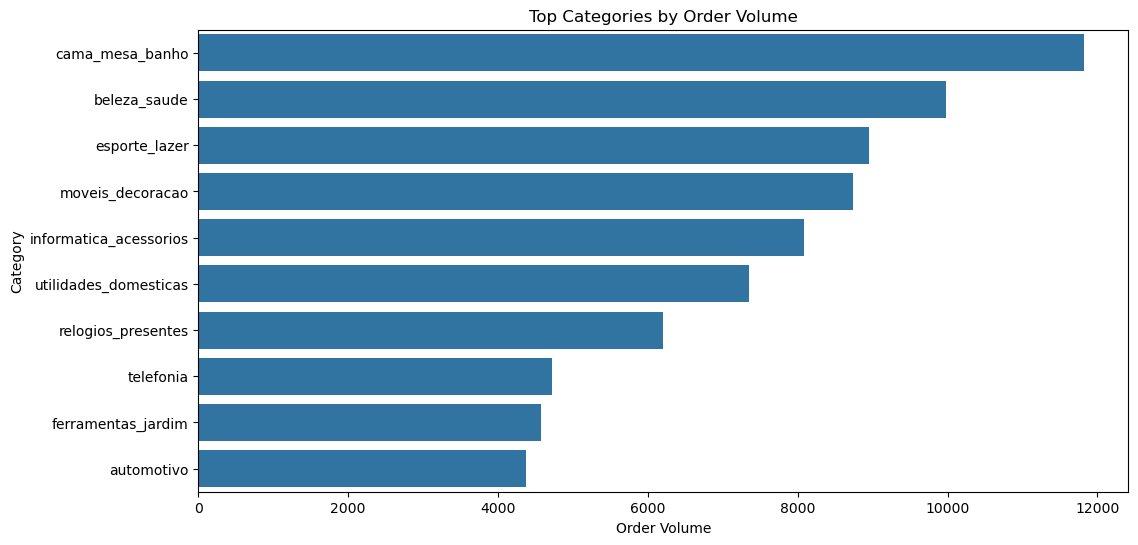

In [13]:
#Order Volume by Category

top_orders = category_analysis.sort_values(
    by='order_volume',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_orders,
    x='order_volume',
    y='product_category_name'
)

plt.title('Top Categories by Order Volume')
plt.xlabel('Order Volume')
plt.ylabel('Category')

plt.show()

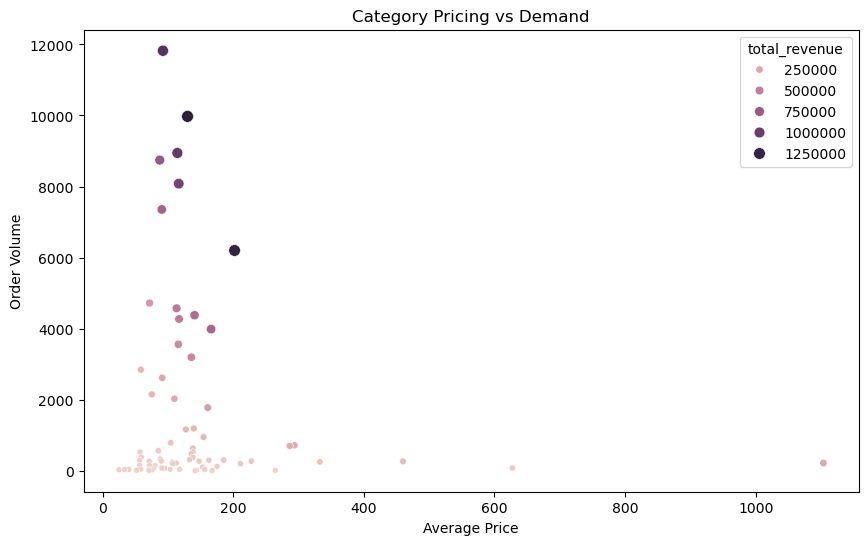

In [14]:
#Scatter plot 
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=category_analysis,
    x='average_price',
    y='order_volume',
    size='total_revenue',
    hue='total_revenue'
)

plt.title('Category Pricing vs Demand')
plt.xlabel('Average Price')
plt.ylabel('Order Volume')

plt.show()

Demand Analysis

In [15]:
#Monthly Order Demand Trend
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
#aggregate monthly orders
monthly_orders = df.groupby(
    'order_month'
)['order_id'].count().reset_index()

monthly_orders.columns = [
    'month',
    'total_orders'
]




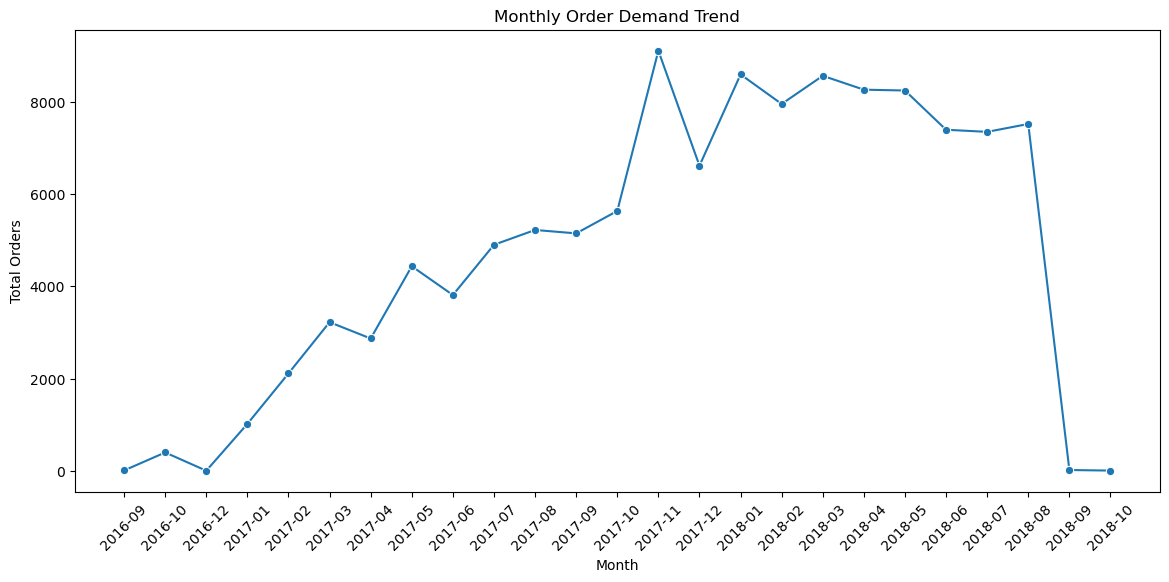

In [16]:
#Visulaization
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_orders,
    x='month',
    y='total_orders',
    marker='o'
)

plt.xticks(rotation=45)

plt.title('Monthly Order Demand Trend')
plt.xlabel('Month')
plt.ylabel('Total Orders')

plt.show()

In [17]:
#Monthly Revenue Trend
revenue_trend = df.groupby(
    'order_month'
)['payment_value'].sum().reset_index()

revenue_trend.columns = [
    'month',
    'total_revenue'
]

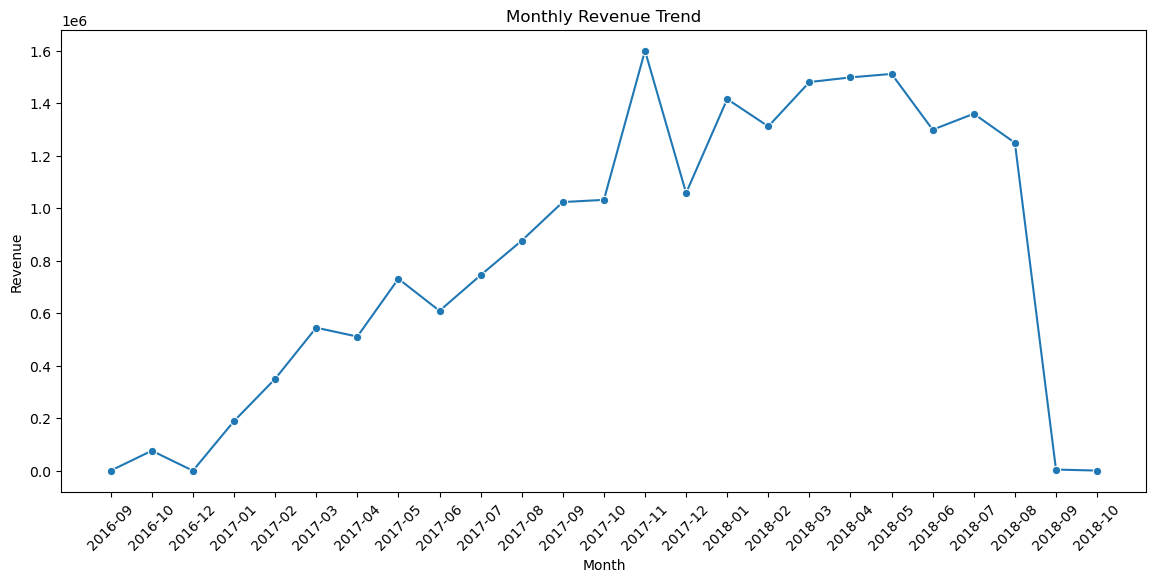

Revenue trends generally follow order demand patterns, although certain periods generate disproportionately higher revenue, potentially indicating stronger premium-category sales or higher average order values.
The Revenue Trend shows a period of high but fluctuating revenue, a strong upward trend from October 2016 to August 2018, a peak around November 2017 and a sharp decline near August 2018 to September 2018.


In [18]:
#Visualization
plt.figure(figsize=(14,6))

sns.lineplot(
    data=revenue_trend,
    x='month',
    y='total_revenue',
    marker='o'
)

plt.xticks(rotation=45)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

print("Revenue trends generally follow order demand patterns, although certain periods generate disproportionately higher revenue, potentially indicating stronger premium-category sales or higher average order values.")
print("The Revenue Trend shows a period of high but fluctuating revenue, a strong upward trend from October 2016 to August 2018, a peak around November 2017 and a sharp decline near August 2018 to September 2018.")


In [19]:
#Demand by Product Category


#Aggregate category demand
category_demand = df.groupby(
    'product_category_name'
)['order_id'].count().reset_index()

category_demand.columns = [
    'category',
    'order_volume'
]

category_demand = category_demand.sort_values(
    by='order_volume',
    ascending=False
)

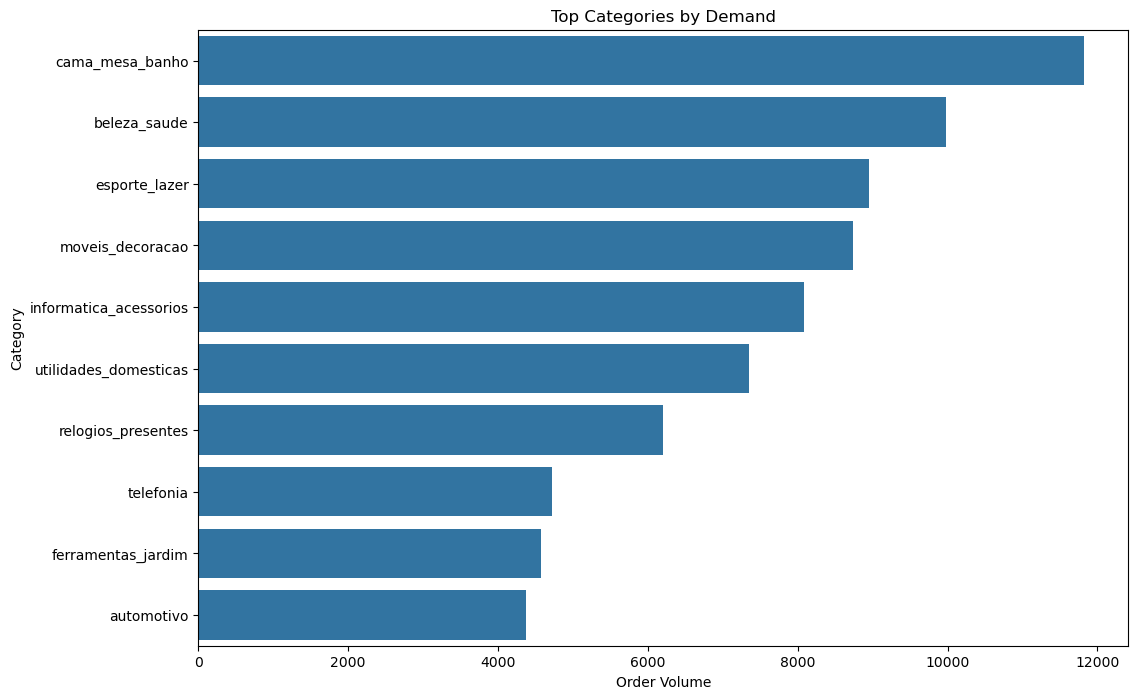

In [20]:
#Visualization

plt.figure(figsize=(12,8))

sns.barplot(
    data=category_demand.head(10),
    x='order_volume',
    y='category'
)

plt.title('Top Categories by Demand')
plt.xlabel('Order Volume')
plt.ylabel('Category')

plt.show()

In [21]:
#Seasonal Category Demand
df['purchase_month'] = (
    df['order_purchase_timestamp'].dt.month
)
monthly_category = df.groupby(
    ['purchase_month', 'product_category_name']
)['order_id'].count().reset_index()


#select top categories
top_categories = category_demand.head(5)['category']

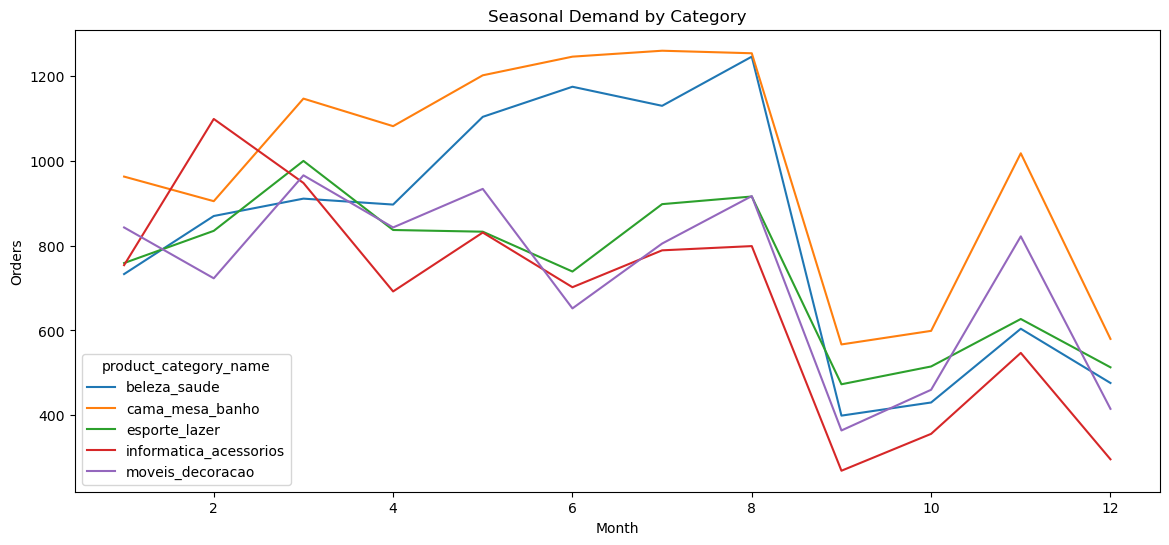

In [22]:
#filtered categories
monthly_category_filtered = monthly_category[
    monthly_category['product_category_name']
    .isin(top_categories)
]

#Visualization
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_category_filtered,
    x='purchase_month',
    y='order_id',
    hue='product_category_name'
)

plt.title('Seasonal Demand by Category')
plt.xlabel('Month')
plt.ylabel('Orders')

plt.show()

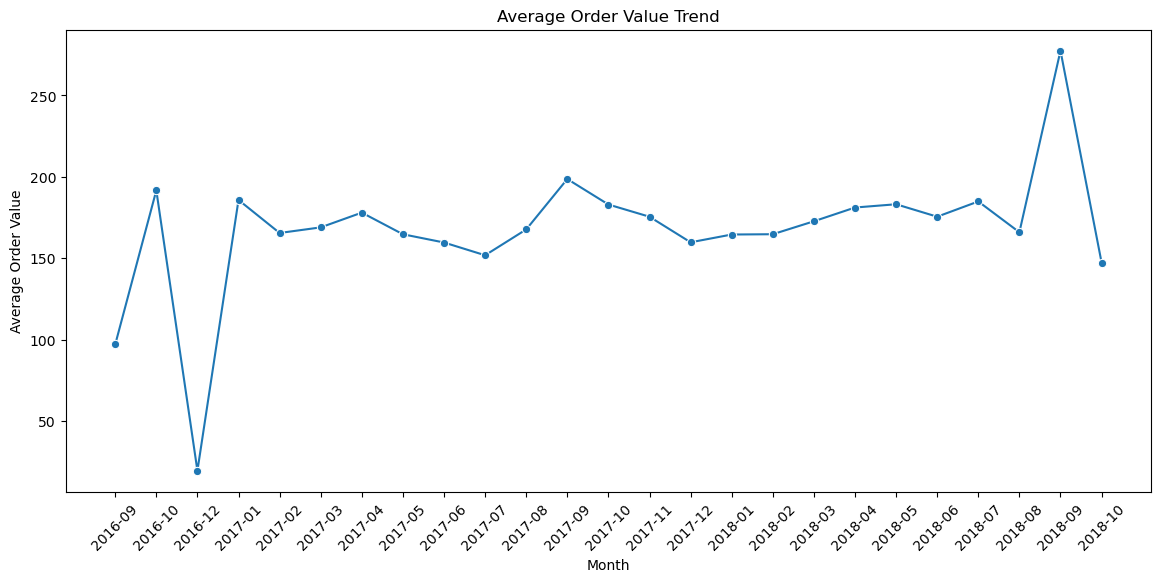

In [23]:
#Average Order Value Trend

aov = df.groupby(
    'order_month'
)['payment_value'].mean().reset_index()

aov.columns = [
    'month',
    'average_order_value'
]

#Visualization
plt.figure(figsize=(14,6))

sns.lineplot(
    data=aov,
    x='month',
    y='average_order_value',
    marker='o'
)

plt.xticks(rotation=45)

plt.title('Average Order Value Trend')
plt.xlabel('Month')
plt.ylabel('Average Order Value')

plt.show()

In [24]:
#Delivery and Operational Performance Analysis


#calculate delivery days
df['delivery_days'] = (
    pd.to_datetime(df['order_delivered_customer_date'])
    -
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

df['delivery_days'].describe()

count    115037.000000
mean         12.019237
std           9.461440
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

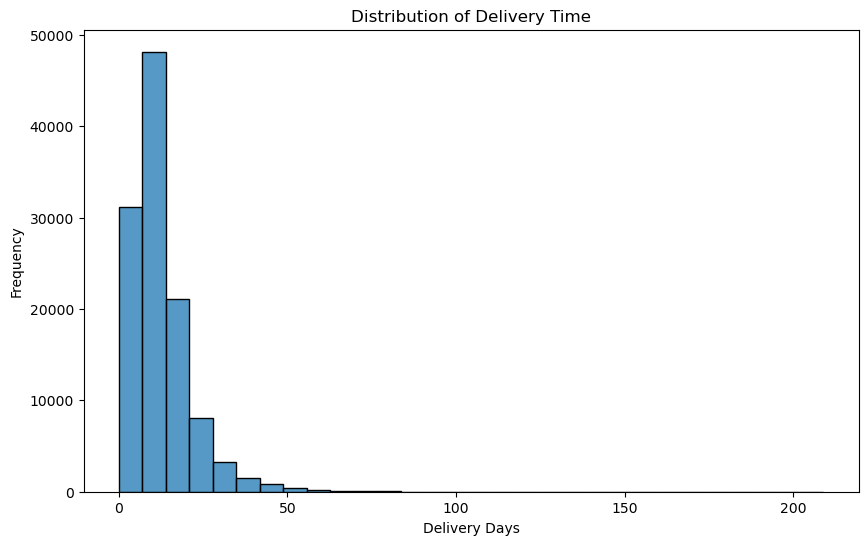

Most orders are delivered within a relatively concentrated time range, although a subset of orders experiences significantly longer delivery periods, indicating operational variability.


In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['delivery_days'],
    bins=30
)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Days')
plt.ylabel('Frequency')

plt.show()

print("Most orders are delivered within a relatively concentrated time range, although a subset of orders experiences significantly longer delivery periods, indicating operational variability.")

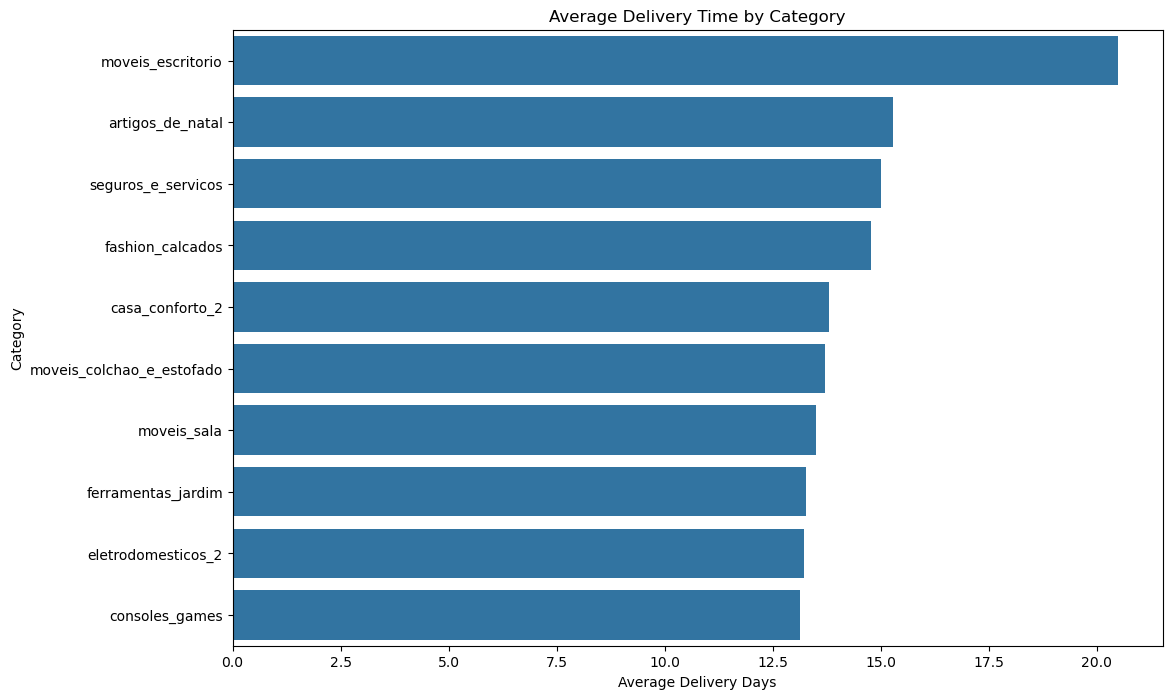

In [26]:
#Delivery Time by Category

category_delivery = df.groupby(
    'product_category_name'
)['delivery_days'].mean().reset_index()

category_delivery = category_delivery.sort_values(
    by='delivery_days',
    ascending=False
)



#Visualization
plt.figure(figsize=(12,8))

sns.barplot(
    data=category_delivery.head(10),
    x='delivery_days',
    y='product_category_name'
)

plt.title('Average Delivery Time by Category')
plt.xlabel('Average Delivery Days')
plt.ylabel('Category')

plt.show()

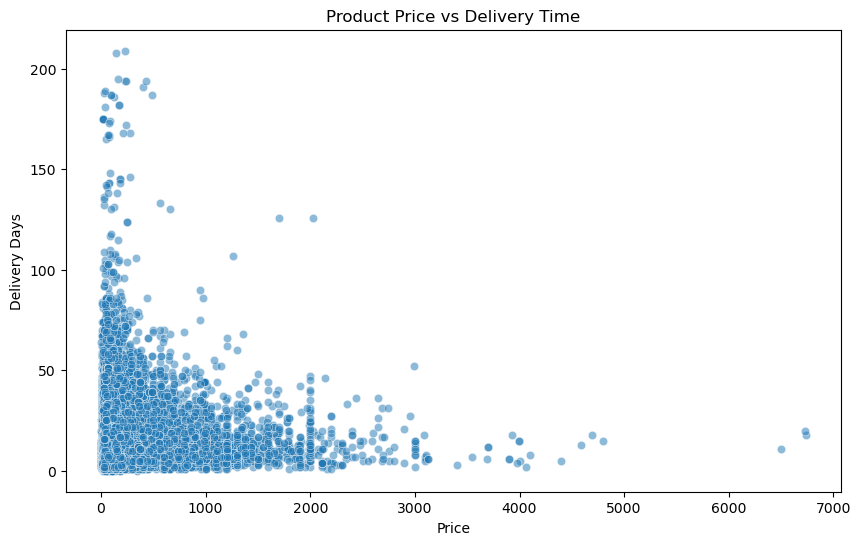

In [27]:
#Delivery Time vs Price

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='price',
    y='delivery_days',
    alpha=0.5
)

plt.title('Product Price vs Delivery Time')
plt.xlabel('Price')
plt.ylabel('Delivery Days')

plt.show()

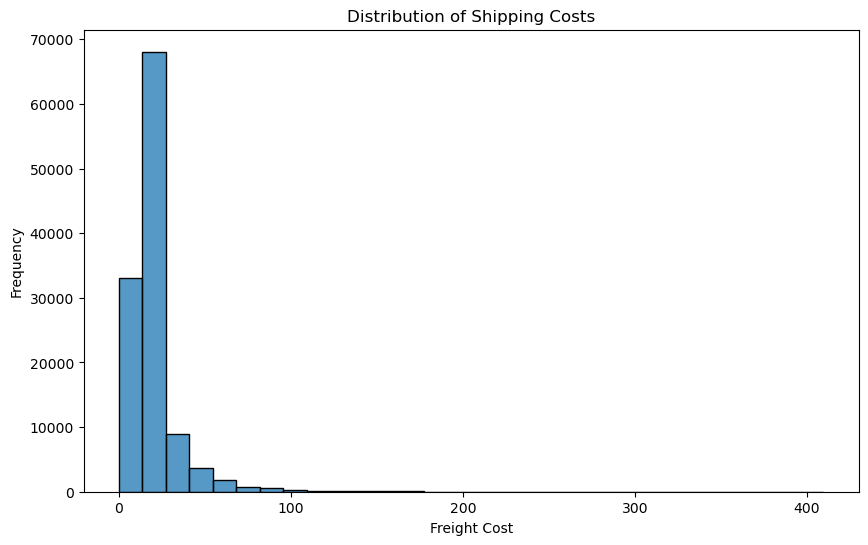

In [28]:
#Freight Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    df['freight_value'],
    bins=30
)

plt.title('Distribution of Shipping Costs')
plt.xlabel('Freight Cost')
plt.ylabel('Frequency')

plt.show()

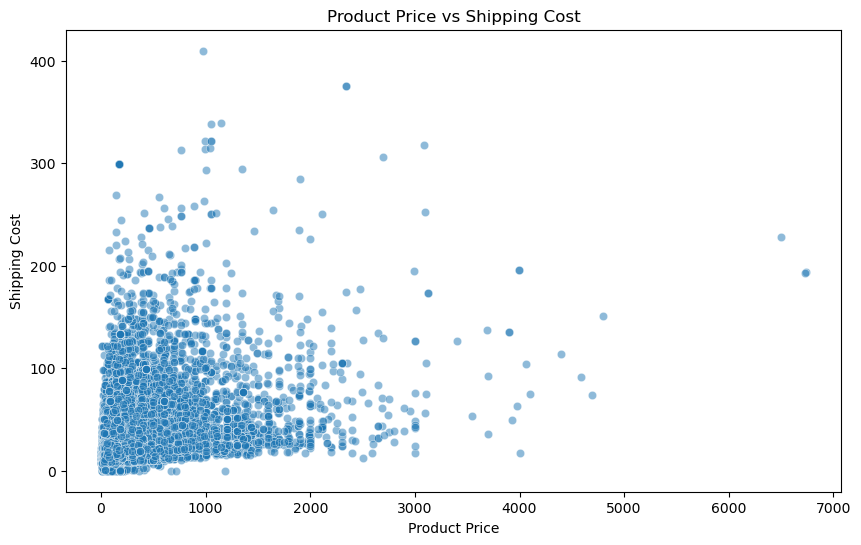

In [29]:
#Freight Cost vs Product price

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='price',
    y='freight_value',
    alpha=0.5
)

plt.title('Product Price vs Shipping Cost')
plt.xlabel('Product Price')
plt.ylabel('Shipping Cost')

plt.show()

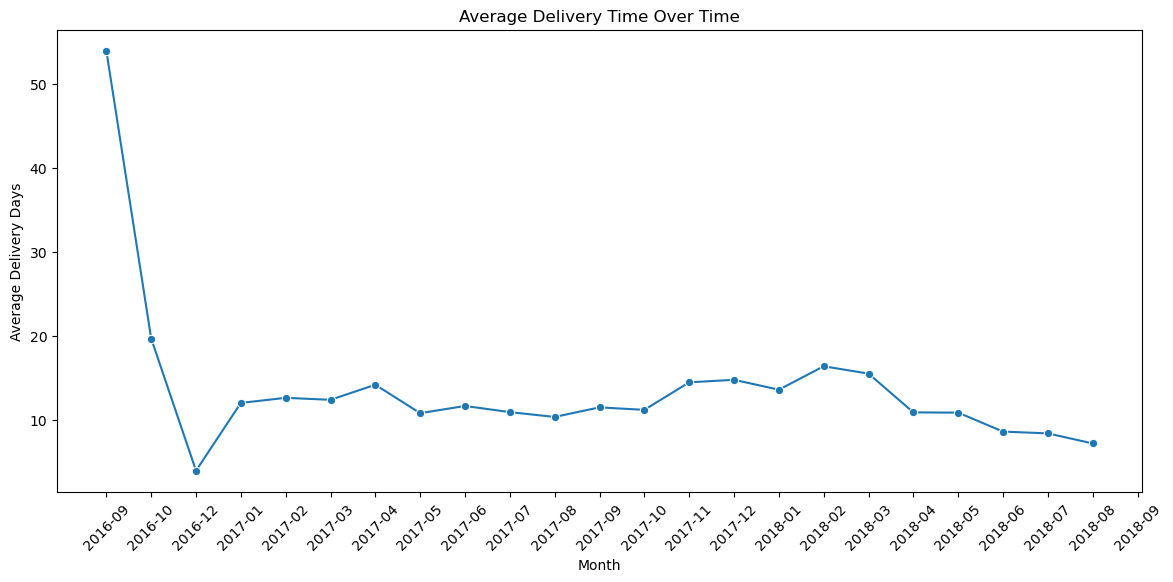

In [30]:
#Monthly Delivery Trends

delivery_trend = df.groupby(
    'order_month'
)['delivery_days'].mean().reset_index()


#Visualization

plt.figure(figsize=(14,6))

sns.lineplot(
    data=delivery_trend,
    x='order_month',
    y='delivery_days',
    marker='o'
)

plt.xticks(rotation=45)

plt.title('Average Delivery Time Over Time')
plt.xlabel('Month')
plt.ylabel('Average Delivery Days')

plt.show()

# Commercial Insights & Recommendations

## Executive Summary

This analysis combines pricing, demand, revenue, and delivery performance to understand commercial patterns in the Brazilian e-commerce marketplace. The results show that revenue is driven by a combination of high-volume categories and premium-priced categories, while delivery performance varies across product groups and may influence customer experience and operational efficiency.

Overall, the marketplace shows strong commercial concentration in a limited number of categories, with clear opportunities for pricing optimization, demand planning, and logistics improvement.

---

## 1. Pricing & Revenue Insights

The category pricing analysis shows that the highest revenue-generating categories are not always the categories with the highest average price.  

For example, categories such as `beleza_saude`, `relogios_presentes`, `cama_mesa_banho`, `esporte_lazer`, and `informatica_acessorios` are among the strongest revenue contributors. This indicates that commercial performance depends on both price level and order volume.

Some categories, such as `relogios_presentes`, show relatively high average prices while still generating strong revenue, suggesting premium-category potential. Other categories, such as `cama_mesa_banho`, generate high revenue mainly through strong order volume rather than premium pricing.

**Business interpretation:**  
A successful pricing strategy should not focus only on increasing prices. Categories should be segmented based on whether they are revenue-driven by volume, premium pricing, or a combination of both.

---

## 2. Demand Insights

The demand analysis shows that order volume is concentrated in a limited number of product categories. Categories with high order volume represent strong customer demand and may be important for marketplace traffic and customer retention.

The monthly order trend indicates growth from late 2016 into 2018, followed by a sharp decline near the end of the available period. Revenue follows a similar pattern, although some months show stronger revenue performance, possibly due to higher-value purchases or changes in product mix.

**Business interpretation:**  
Demand planning should focus on the highest-volume categories because they are likely to have the greatest impact on operational workload, inventory planning, and pricing decisions.

---

## 3. Price vs Demand Tradeoff

The category pricing vs demand scatter plot highlights different commercial category profiles:

- High-price / low-volume categories may represent premium or niche segments.
- Low-price / high-volume categories may represent mass-market demand.
- High-revenue categories often balance sufficient order volume with attractive pricing levels.

**Business interpretation:**  
Different categories require different pricing strategies. High-volume categories may benefit from small price adjustments due to their larger sales base, while premium categories may benefit more from value-based pricing and positioning.

---

## 4. Delivery & Operational Insights

The average delivery time is approximately 12 days, with most orders delivered within a relatively concentrated time range. However, the maximum delivery time reaches over 200 days, showing that a small number of orders experience extreme delays.

Delivery time also varies by product category, suggesting that some product groups may be more operationally complex to fulfill. This could be related to product size, seller location, logistics network, or supply-chain limitations.

**Business interpretation:**  
Delivery performance should be monitored together with pricing and demand, because operational delays can reduce the attractiveness of certain categories even when demand is strong.

---

## 5. Shipping Cost Insights

The freight cost analysis shows that shipping costs vary significantly across orders. The relationship between product price and freight value is commercially important because low-priced products with relatively high shipping costs may become less attractive to customers.

**Business interpretation:**  
Shipping cost should be considered part of the total customer price. For lower-priced products, high freight costs may reduce conversion potential and weaken competitiveness.

---

# Business Recommendations

## Recommendation 1: Segment Categories by Pricing Strategy

Categories should be grouped into different pricing strategy segments:

- Premium categories: higher average price, lower volume, strong revenue potential
- Volume categories: lower average price, high order volume
- Balanced categories: strong revenue through both price and volume

This allows pricing decisions to be more targeted rather than applying one general pricing logic across all categories.

---

## Recommendation 2: Optimize High-Volume Categories Carefully

High-demand categories should be prioritized for pricing analysis because even small price changes can have a large revenue impact.

For these categories, pricing should be monitored closely against order volume to avoid reducing demand through overly aggressive price increases.

---

## Recommendation 3: Protect Premium Revenue Categories

Categories with high average prices and strong revenue contribution should be managed with a premium positioning strategy.

Instead of competing only on lower prices, these categories may benefit from:
- better product presentation
- stronger delivery reliability
- targeted promotions
- value-based pricing

---

## Recommendation 4: Monitor Delivery Performance by Category

Categories with longer average delivery times should be reviewed from an operational perspective.

Improving delivery performance in these categories could support:
- better customer experience
- stronger repeat purchase potential
- improved marketplace competitiveness

---

## Recommendation 5: Include Freight Cost in Pricing Decisions

Shipping cost should be included in pricing analysis because customers evaluate the total purchase cost, not only the product price.

For products where freight cost is high relative to product price, the business could consider:
- shipping promotions
- bundled pricing
- seller logistics optimization
- minimum order thresholds for reduced shipping

---

## Recommendation 6: Use Demand Trends for Pricing and Planning

Monthly demand and revenue trends should be used to support pricing and promotional planning.

Periods of increasing demand may offer opportunities for:
- targeted promotions
- inventory preparation
- category-specific pricing tests
- campaign planning

---

# Final Conclusion

This project demonstrates how pricing, demand, revenue, and delivery data can be combined to generate commercial insights in an e-commerce environment. The analysis shows that effective pricing decisions require more than average price comparisons; they also need demand behavior, revenue contribution, freight cost, and delivery performance.

The findings support a data-driven approach to pricing and commercial decision-making, helping identify where pricing optimization, operational improvements, and category-level strategies can create business value.